# Elastic plots

This tutorial was prepared by Alexandre Olender: olender@usp.br

This tutorial demonstrates Spiro's plotting utilities in the isotropic elastic wave problem. We will plot:
1. A high-resolution velocity model;
2. Wavefield solved at a given timestep;
3. An individual receiver trace;
4. A complete shot record."

In [2]:
# Code in this cell enables plotting in the notebook
%matplotlib inline

import spyro
import numpy as np

Let us begin by setting up an isotropic elastic forward problem in Spiro. Since we will also talk a bit about numerical verification compared to an analytical solution, we will focus on the homogeneous case.

In [8]:
vp = 1.5
vs = 1.0
rho = 0.1

In [ ]:
source_z = -1.1
receiver_z = -1.9
edge_length = 0.1
receiver_locations = spyro.create_transect((receiver_z, 1.2), (receiver_z, 1.8), 300)

dictionary = {
    "options": {
        "cell_type": "Q",
        "variant": "lumped",
        "degree": 4,
        "dimension": 2,
    },
    "parallelism": {
        "type": "automatic",
    },
    "mesh": {
        "length_z": 3.0,
        "length_x": 3.0,
        "mesh_file": None,
        "mesh_type": "firedrake_mesh",
    },
    "acquisition": {
        "source_type": "ricker",
        "source_locations": [(source_z, 1.5)],
        "frequency": 5.0,
        "delay": 0.2,
        "delay_type": "time",
        "receiver_locations": receiver_locations,
        "amplitude": np.array([0.0, 1.0]),
    },
    "time_axis": {
        "initial_time": 0.0,
        "final_time": 1.5,
        "dt": 0.001,
        "output_frequency": 100,
        "gradient_sampling_frequency": 1,
    },
    "visualization": {
        "forward_output": False,
        "fwi_velocity_model_output": False,
        "gradient_output": False,
        "adjoint_output": False,
        "debug_output": False,
    },
}

dictionary["synthetic_data"] = {
    "type": "object",
    "density": rho,
    "p_wave_velocity": vp,
    "s_wave_velocity": vs,
    "real_velocity_file": None,
}
dictionary["acquisition"]["amplitude"] = np.array([0.0, 1.0])
wave = spyro.IsotropicWave(dictionary)
wave.set_mesh(input_mesh_parameters={"edge_length": edge_length, "periodic": False})



Parallelism type: automatic
No Absorbing Boundary Conditions (ABCs) applied.
Pad length will be determined with HABC criterion
Mesh incomplete: 'firedrake_mesh' requires either 'edge_length' or 'cells_per_wavelength'.
Mesh incomplete: 'firedrake_mesh' requires either 'edge_length' or 'cells_per_wavelength'.
Skipping mesh generation, since we don't have all the parameters
Creating firedrake_mesh type mesh.
Mesh Created with 961 Nodes and 900 Area Elements


/workspaces/qol_upgrades/spyro/solvers/wave.py:171: UserWarning: No mesh file, Firedrake mesh will be automatically generated.
  warnings.warn(


Let us propagate our wave and look at the last result.

In [5]:
wave.forward_solve()


Solving Forward Problem
Simulation time is:        0.0 seconds


/usr/local/lib/python3.12/dist-packages/ufl/utils/sorting.py:88: UserWarning: Applying str() to a metadata value of type TensorProductQuadratureRule, don't know if this is safe.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/ufl/utils/sorting.py:88: UserWarning: Applying str() to a metadata value of type TensorProductQuadratureRule, don't know if this is safe.
  warnings.warn(


Simulation time is:        0.1 seconds
Simulation time is:        0.2 seconds
Simulation time is:        0.3 seconds
Simulation time is:        0.4 seconds
Simulation time is:        0.5 seconds
Simulation time is:        0.6 seconds
Simulation time is:        0.7 seconds
Simulation time is:        0.8 seconds
Simulation time is:        0.9 seconds
Simulation time is:        1.0 seconds
Simulation time is:        1.1 seconds
Simulation time is:        1.2 seconds
Simulation time is:        1.3 seconds
Simulation time is:        1.4 seconds
Simulation time is:        1.5 seconds


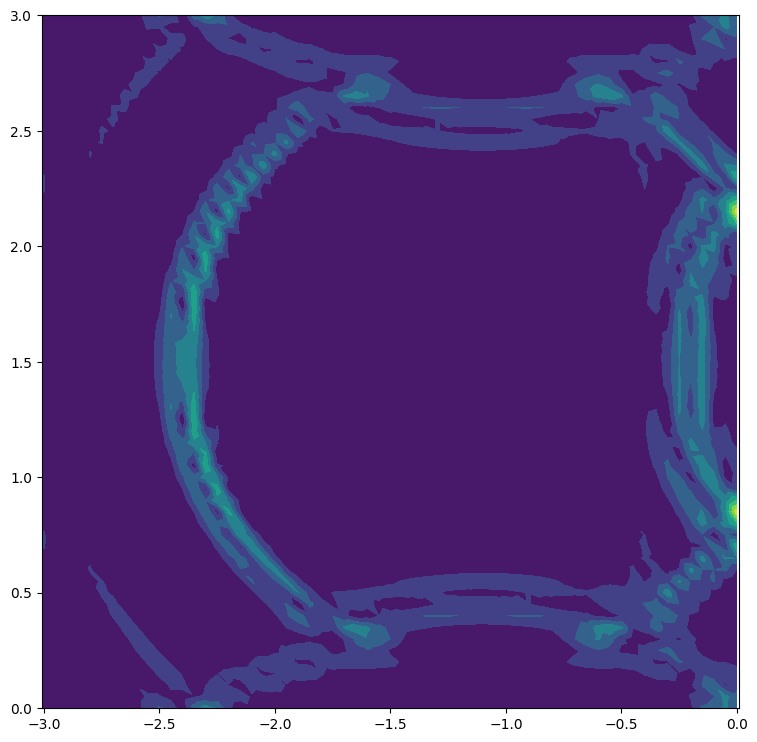

In [6]:
spyro.plots.plot_function(wave.u_n)

This image has some problems:
* We are seing a lot of mesh artifacts, tehrefore we could increase the resolution.
* There's significant reflection, so we either add an absorbing boundary of some kind or increase mesh size and reposition our acquisition geometry so this reflection does not show up during our simulation time.

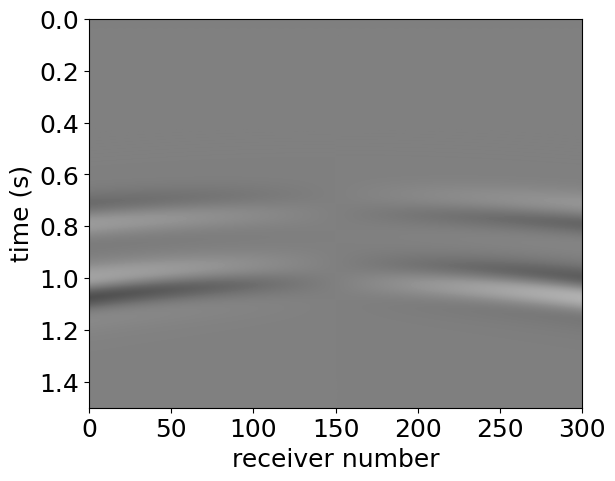

In [6]:
last_displacement = wave.u_n.dat.data[:]
u_max = np.max(np.abs(last_displacement[:, 0]))
spyro.plots.plot_shots(wave, contour_lines=100, vmin=-u_max, vmax=u_max, show=True, out_index=0)

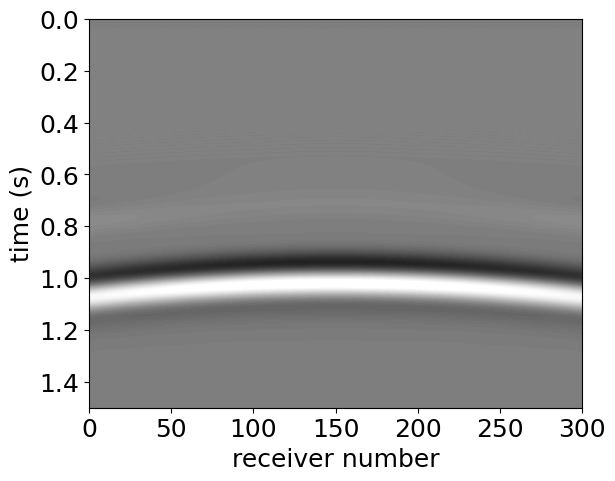

In [7]:

u_max = np.max(np.abs(last_displacement[:, 1]))
spyro.plots.plot_shots(wave, contour_lines=100, vmin=-u_max, vmax=u_max, show=True, out_index=1)